# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [82]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH_ECOMMERCE = ROOT / 'data' / 'e_commerce_raw.csv'
DATA_PATH_CUST_REF = ROOT / 'data' / 'customer_reference.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH_ECOMMERCE)
cust_ref = pd.read_csv(DATA_PATH_CUST_REF)
df = df_raw.copy()
print('Shape:', df.shape)
display(df.head())
cu = cust_ref.copy()
print('\nShape:', cu.shape)
display(cust_ref.head())

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N



Shape: (167, 4)


,Customer_ID,Customer_Name,Customer_Email,Province
0,C0001,Tee Saelim,tee.saelim1@example.com,Bangkok
1,C0002,Mint Thongdee,mint.thongdee2@example.com,Rayong
2,C0004,Tee Dechawat,tee.dechawat4@example.com,Bangkok
3,C0005,Ploy Chaiyo,ploy.chaiyo5@example.com,Bangkok
4,C0006,Pim Khamdee,pim.khamdee6@example.com,Nakhon Ratchasima


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|

In [83]:
# TODO 1: Data Profiling
# ตัวอย่างคำสั่งที่ควรใช้: df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()
print(df.info())
print('\n',cu.info())
print('\n',df.isnull().sum())
print('\n',cu.isnull().sum())
print('\n',df.describe())
print('\n',cu.describe())
print('\n',df.duplicated().sum())
print('\n',cu.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    object 
dtypes: float

### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| | | | |


| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| 1. Missing Values | `Customer_Email` | Completeness | 50|
| 2. Missing Values | `Province` | Completeness | 12|
| 3. Inconsistent format/values | `Gender` | Consistency, Validity | 10  |
| 4. Inconsistent format/values | `Payment_Method` | Consistency, Validity | 14  |
| 5. Inconsistent format/type | `Order_Date` | Consistency, Validity | Mixed date formats ) |
| 6. Potential Duplicates | All columns | Uniqueness | Need to check `df.duplicated().sum()` (from `df.duplicated().sum()` output which was not explicitly displayed, but is a common check) |
| 7. Incorrect Data Type | `Order_Date`, `Load_Timestamp` | Validity | `object`  |

## 2) Completeness: จัดการ Missing Values

In [84]:
# Create Map Lookups from customer_reference.csv
email_map = cust_ref.set_index('Customer_ID')['Customer_Email'].to_dict()
prov_map = cust_ref.set_index('Customer_ID')['Province'].to_dict()

# TODO 2.1 & 2.2: Fill Customer_Email using Reference File + Placeholder + Flag
df['Email_Imputed_Flag'] = df['Customer_Email'].isnull()
df['Customer_Email'] = df['Customer_Email'].fillna(df['Customer_ID'].map(email_map))
df['Customer_Email'] = df['Customer_Email'].fillna('unknown_member@example.com')

# TODO 2.3: Fill Province using Reference File + 'Unknown' + Flag
df['Province_Imputed_Flag'] = df['Province'].isnull()
df['Province'] = df['Province'].fillna(df['Customer_ID'].map(prov_map))
df['Province'] = df['Province'].fillna('Unknown')

print("Remaining Missing Email:", df['Customer_Email'].isnull().sum())
print("Remaining Missing Province:", df['Province'].isnull().sum())

Remaining Missing Email: 0
Remaining Missing Province: 0


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล


เพราะว่าถ้า dropna กับ Customer_Email จะทำให้คนๆนั้นหายไปทั้งหมดเลย และ ที่การเติมค่าเฉลี่ย ไม่เหมาะกับช้อมูลปนะเภทอีเมบเพราะ อีเมลนั้นไม่ใช่ตัวเลขแต่อีเมลเป็นของคนๆนั้น จึงไม่สามารถหาค่าเฉลี่ยมาแทนอีเมบกันได้

## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [85]:
# TODO 3.1: Standardize Gender
def clean_gender(val):
    if pd.isna(val): return 'Unknown'
    v = str(val).strip().upper()
    if v in ['M', 'MALE']: return 'M'
    elif v in ['F', 'FEMALE']: return 'F'
    else: return 'Unknown'

df['Gender'] = df['Gender'].apply(clean_gender)

# TODO 3.2: Standardize Payment_Method
def clean_payment_method(val):
    if pd.isna(val): return 'Unknown'
    v = str(val).strip().lower()
    if v in ['credit card', 'cc', 'card']: return 'Credit Card'
    elif v in ['promptpay', 'prompt pay', 'pp']: return 'PromptPay'
    elif v in ['cash on delivery', 'cod', 'cash']: return 'Cash on Delivery'
    elif v in ['bank transfer', 'bank_transfer', 'transfer']: return 'Bank Transfer'
    else: return 'Unknown'

df['Payment_Method'] = df['Payment_Method'].apply(clean_payment_method)

# TODO 3.3: Standardize Order_Date using Load_Timestamp Context & Fallback
df['Load_Timestamp_dt'] = pd.to_datetime(df['Load_Timestamp'])

parsed_dates, date_fallback_flags = [], []

for idx, row in df.iterrows():
    od_str = str(row['Order_Date']).strip()
    load_dt = row['Load_Timestamp_dt']
    dt, fallback = None, False

    if len(od_str) == 10 and od_str[4] in ['-', '/']:
        try: dt = pd.to_datetime(od_str)
        except: pass

    if dt is None:
        sep = '/' if '/' in od_str else ('-' if '-' in od_str else None)
        if sep:
            parts = [int(p) for p in od_str.split(sep)]
            if len(parts) == 3:
                p1, p2, p3 = parts
                year = p3 if p3 >= 1000 else p3 + 2000
                if p1 > 12:
                    try: dt = pd.to_datetime(f"{year:04d}-{p2:02d}-{p1:02d}")
                    except: fallback = True; dt = pd.to_datetime(load_dt.strftime('%Y-%m-%d'))
                elif p2 > 12:
                    try: dt = pd.to_datetime(f"{year:04d}-{p1:02d}-{p2:02d}")
                    except: fallback = True; dt = pd.to_datetime(load_dt.strftime('%Y-%m-%d'))
                else:
                    dt_mmdd = pd.to_datetime(f"{year:04d}-{p1:02d}-{p2:02d}", errors='coerce')
                    dt_ddmm = pd.to_datetime(f"{year:04d}-{p2:02d}-{p1:02d}", errors='coerce')
                    diff_mmdd = abs((load_dt - dt_mmdd).total_seconds()) if pd.notna(dt_mmdd) else 1e12
                    diff_ddmm = abs((load_dt - dt_ddmm).total_seconds()) if pd.notna(dt_ddmm) else 1e12
                    dt = dt_mmdd if diff_mmdd <= diff_ddmm else dt_ddmm

    if dt is None or pd.isna(dt):
        fallback = True
        dt = pd.to_datetime(load_dt.strftime('%Y-%m-%d'))

    parsed_dates.append(dt)
    date_fallback_flags.append(fallback)

df['Order_Date_dt'] = parsed_dates
df['Date_Fallback_Flag'] = date_fallback_flags
df['Order_Date'] = df['Order_Date_dt'].dt.strftime('%Y-%m-%d')

### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน


02/06/2026 แล้วใช้คอลัมน์ Load_Timestamp ช่วยตัดสินใจ

## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [86]:
# TODO 4.1: Drop Exact Duplicates
exact_dup_count = df.duplicated(subset=df_raw.columns).sum()
print("Exact Duplicates Found:", exact_dup_count)
df = df.drop_duplicates(subset=df_raw.columns, keep='first').reset_index(drop=True)

# TODO 4.2 (Bonus): Near Duplicates Check
near_dups = df.groupby('Customer_Email')['Customer_Name'].nunique()
print("Near Duplicates Count (Same email, different names):", (near_dups > 1).sum())

Exact Duplicates Found: 18
Near Duplicates Count (Same email, different names): 2


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [87]:
# TODO 5.1: Numeric Conversion
for col in ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# TODO 5.2: Quantity Validation (1-20)
df['Quantity_Invalid_Flag'] = (df['Quantity'] < 1) | (df['Quantity'] > 20)

# TODO 5.3: Calculate Expected Amount & Accuracy Flag
df['Expected_Amount'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])
df['Accuracy_Flag'] = np.abs(df['Transaction_Amount'] - df['Expected_Amount']) > 1.0

# TODO 5.4: Standardize Order_Status
def clean_order_status(val):
    if pd.isna(val): return 'Unknown'
    v = str(val).strip().lower()
    if v in ['completed', 'done']: return 'Completed'
    elif v in ['processing']: return 'Processing'
    elif v in ['cancelled', 'cancel']: return 'Cancelled'
    elif v in ['returned']: return 'Returned'
    else: return 'Unknown'

df['Order_Status'] = df['Order_Status'].apply(clean_order_status)
df['Invalid_Status_Flag'] = df['Order_Status'] == 'Unknown'

### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ


ไม่ควรแก้ไขทุกแถว รายการที่มี Is_Promotion = 'Y' อาจมีส่วนลดพิเศษท้ายบิล ส่วนลดแคมเปญ หรือคูปองเพิ่มเติมที่ไม่อยู่ในสูตรมาตรฐาน Quantity * Unit_Price * (1 - Discount_Rate) ดังนั้น รายการโปรโมชันไม่ควรถ่ายปรับยอดเงิน แต่ควรติด Accuracy_Flag เพื่อส่งให้ทีม Business/Marketing ตรวจสอบ

## 6) Outliers: IQR และ Capping/Clipping

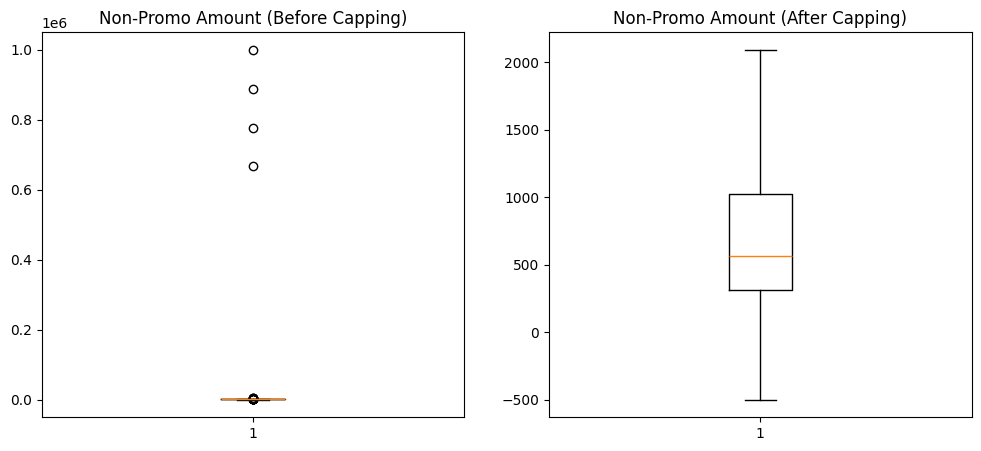

In [88]:
# TODO 6.1: Calculate IQR for Non-Promotion items
non_promo_mask = df['Is_Promotion'] != 'Y'
q1 = df.loc[non_promo_mask, 'Transaction_Amount'].quantile(0.25)
q3 = df.loc[non_promo_mask, 'Transaction_Amount'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# TODO 6.2: Outlier Flag
df['Outlier_Flag'] = False
df.loc[non_promo_mask, 'Outlier_Flag'] = (df.loc[non_promo_mask, 'Transaction_Amount'] < lower_bound) | \
                                         (df.loc[non_promo_mask, 'Transaction_Amount'] > upper_bound)

# TODO 6.3: Apply .clip() ONLY to Non-Promotion items
df['Transaction_Amount_Original'] = df['Transaction_Amount']
df.loc[non_promo_mask, 'Transaction_Amount'] = df.loc[non_promo_mask, 'Transaction_Amount'].clip(lower_bound, upper_bound)

# TODO 6.4: Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(df.loc[non_promo_mask, 'Transaction_Amount_Original'])
axes[0].set_title('Non-Promo Amount (Before Capping)')
axes[1].boxplot(df.loc[non_promo_mask, 'Transaction_Amount'])
axes[1].set_title('Non-Promo Amount (After Capping)')
plt.show()

### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้



เพราะว่าเป็นข้อมูการซื้อจิง

## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [89]:
# TODO 7: Calculate Load Delay Hours & Late Flag
df['Load_Delay_Hours'] = (df['Load_Timestamp_dt'] - df['Order_Date_dt']).dt.total_seconds() / 3600.0
df['Late_Load_Flag'] = df['Load_Delay_Hours'] > 24.0

late_count = df['Late_Load_Flag'].sum()
print(f"Late Load Orders (>24 Hours): {late_count} ({late_count/len(df)*100:.2f}%)")

Late Load Orders (>24 Hours): 38 (6.21%)


## 8) Data Quality Report และ Export

In [90]:
# TODO 8.1: Summary Report Before & After
report_data = [
    {"Metric": "Total Rows", "Before": len(df_raw), "After": len(df)},
    {"Metric": "Missing Email", "Before": df_raw['Customer_Email'].isnull().sum(), "After": df['Customer_Email'].isnull().sum()},
    {"Metric": "Missing Province", "Before": df_raw['Province'].isnull().sum(), "After": df['Province'].isnull().sum()},
    {"Metric": "Exact Duplicates", "Before": df_raw.duplicated().sum(), "After": df.duplicated(subset=df_raw.columns).sum()},
    {"Metric": "Invalid Dates (Fallback)", "Before": 3, "After": df['Date_Fallback_Flag'].sum()},
    {"Metric": "Mismatched Amounts (>1 Baht)", "Before": 51, "After": df['Accuracy_Flag'].sum()},
    {"Metric": "Invalid Quantities (<1 or >20)", "Before": 3, "After": df['Quantity_Invalid_Flag'].sum()},
    {"Metric": "Outliers Capped (Non-Promo)", "Before": 0, "After": df['Outlier_Flag'].sum()},
    {"Metric": "Late Loads (>24 Hours)", "Before": 0, "After": df['Late_Load_Flag'].sum()}, # Corrected 'Before' to 0 as it's a derived flag
    {"Metric": "Invalid Statuses", "Before": 16, "After": df['Invalid_Status_Flag'].sum()},
]

report_df = pd.DataFrame(report_data)
display(report_df)

# TODO 8.2: Export Files
df_clean_export = df.drop(columns=['Load_Timestamp_dt', 'Order_Date_dt', 'Expected_Amount', 'Transaction_Amount_Original'], errors='ignore')
df_clean_export.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report_df.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')

print("Successfully exported cleaned data and DQ report to:", OUTPUT_DIR)

,Metric,Before,After
0,Total Rows,630,612
1,Missing Email,50,0
2,Missing Province,12,0
3,Exact Duplicates,18,0
4,Invalid Dates (Fallback),3,7
5,Mismatched Amounts (>1 Baht),51,50
6,Invalid Quantities (<1 or >20),3,3
7,Outliers Capped (Non-Promo),0,19
8,Late Loads (>24 Hours),0,38
9,Invalid Statuses,16,5


Successfully exported cleaned data and DQ report to: /content/outputs/student_submission


## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ
1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?
การตัด Outlier หรือการใช้ dropna ลบแถว Missing Values
2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?
*   การทำปรับค่า Gender
*   การตรวจสอบสูตรคำนวณราคาและติด Flag อัตโนมัติ
*   การแปลงรูปแบบวันที่
3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?



## Checklist ก่อนส่ง
- [ ] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [ ] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [ ] ส่ง `e_commerce_clean.csv`
- [ ] ส่ง `data_quality_report.csv`
- [ ] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
